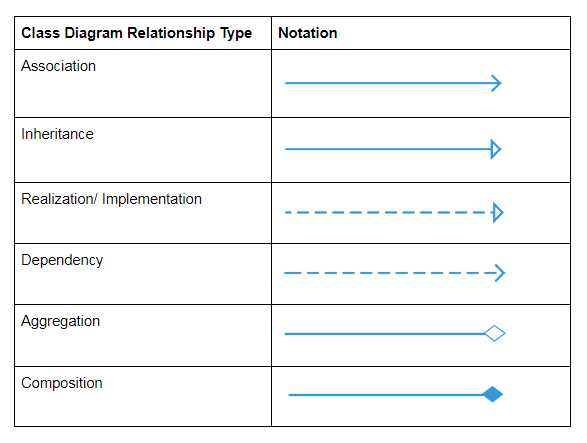

# Resumo rápido dos relacionamentos

| Relacionamento | Ideia principal | Sinal visual na UML |
|---|---|---|
| Associação | se relaciona com | linha contínua |
| Herança | é um tipo de | linha contínua com triângulo |
| Realização | implementa contrato | linha tracejada com triângulo |
| Dependência | usa temporariamente | linha tracejada com seta |
| Agregação | tem partes independentes | losango branco |
| Composição | tem partes dependentes | losango preto |

---

## Macete mental
- **Associação** = se relaciona
- **Herança** = é um tipo de
- **Realização** = implementa
- **Dependência** = usa
- **Agregação** = tem, mas as partes vivem sozinhas
- **Composição** = tem, e as partes dependem do todo

# Associação

É uma ligação comum entre objetos.  
Uma classe **conhece**, **usa** ou **mantém referência** para outra.

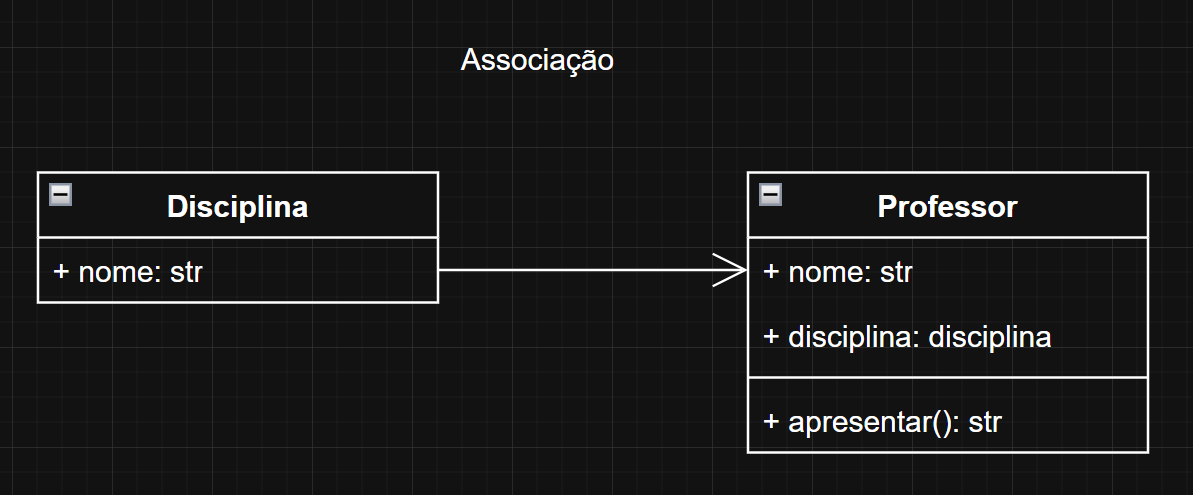

In [ ]:
class Disciplina:
  def __init__(self, nome):
    self.nome = nome

class Professor:
  def __init__(self, nome, disciplina):
    self.nome = nome
    self.disciplina = disciplina # associação com Disciplina

  def apresentar(self): # método
    print(f"Professor: {self.nome}")
    print(f"Disciplina que leciona: {self.disciplina.nome}")

disciplina_python = Disciplina("Python para biruleibis") # disciplina_python recebe uma instancia da classe disciplina
professor_cuca = Professor("Cuca", disciplina_python)

professor_cuca.apresentar()

Professor: Cuca
Disciplina que leciona: Python para biruleibis


A **herança** acontece quando uma classe mais específica herda características de uma classe mais geral.

### Como aparece na UML
- linha contínua
- triângulo vazado apontando para a classe mais geral

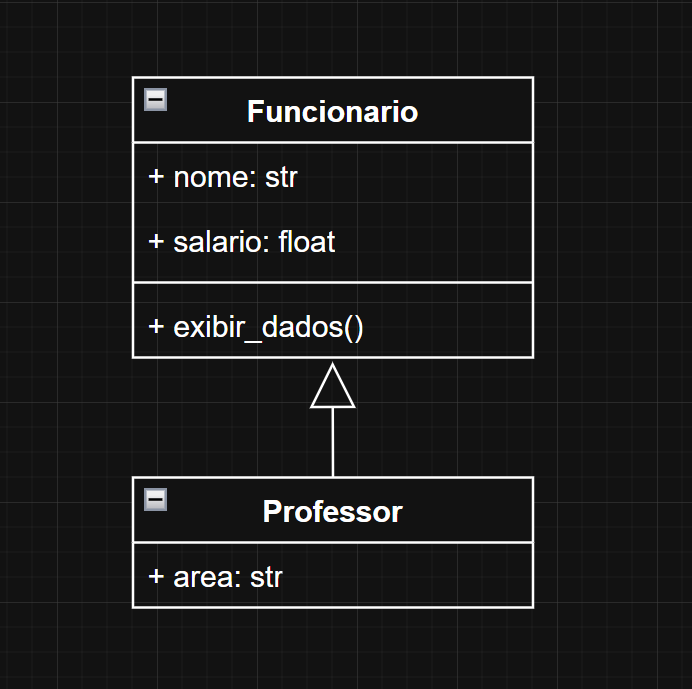

In [ ]:
class Funcionario:
  def __init__(self, nome, salario):
    self.nome = nome
    self.salario = salario

  def exibir_dados(self):
    print(f"Funcionario: {self.nome}")
    print(f"Salário: R$ {self.salario:.2f}")

class Professor(Funcionario): #Herança
  def __init__(self, nome, salario, area):
    super().__init__(nome, salario)
    self.area = area
  def exibir_dados(self):
    super().exibir_dados()
    print(f"Área: {self.area}")

prof = Professor("Marina", 4500, "Tecnologia")
prof.exibir_dados()

Funcionario: Marina
Salário: R$ 4500.00
Área: Tecnologia


## Realização / Implementação
A realização indica que uma classe **implementa um contrato**.

Em Python, isso costuma ser representado com:
- classes abstratas;
- interfaces simuladas com `ABC` e `abstractmethod`.

### Como aparece na UML
- linha tracejada
- triângulo vazado

In [2]:
from abc import ABC, abstractclassmethod

In [10]:
class FormaPagamento(ABC):
  @abstractclassmethod
  def pagar(self, valor):
    pass

class Pix(FormaPagamento):
  def pagar(self, valor):
    print(f"Pagamento de R$ {valor:.2f} realizado via PIX")

class Cartao(FormaPagamento):
  def pagar(self, valor):
    print(f"Pagamento de R$ {valor:.2f} realizado via Cartao")

bandeira = Pix()
pedro = Cartao()

#Pix().pagar(50)
pedro.pagar(230)

#pagamento3 = FormaPagamento()

Pagamento de R$ 230.00 realizado via Cartao


# 4) Dependência

## Conceito
A **dependência** representa um uso mais fraco e temporário.

Uma classe não mantém necessariamente a outra como parte fixa da sua estrutura, mas a utiliza em algum método.

### Como aparece na UML
- linha tracejada
- seta simples

### Leitura simples
> "Usa temporariamente"

---

## Exemplo de contexto
Um sistema gera relatórios e usa uma impressora apenas no momento da impressão.

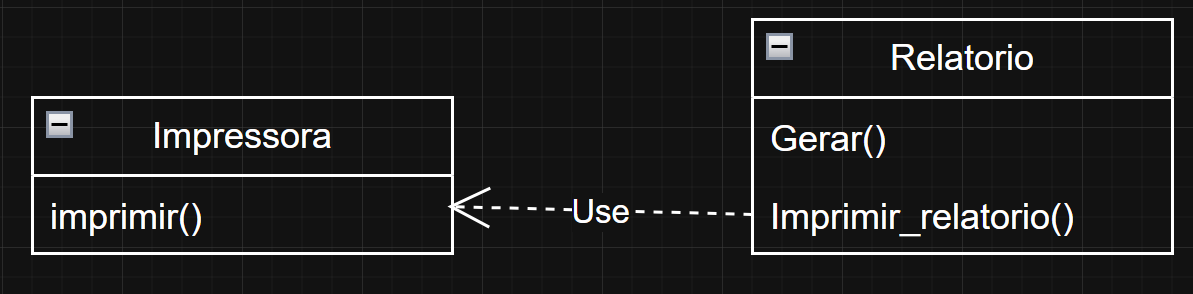

In [11]:
class Impressora:
  def imprimir(self, texto):
    print("==IMPRIMINDO==")
    print(texto)
    print("==============")

class Relatorio:
  def gerar(self):
    return "relatorio mensal: vendas em alta"

  def imprimir_relatorio(self, impressora): #dependencia
    conteudo = self.gerar()
    impressora.imprimir(conteudo)

impressora_hp = Impressora()
relatorio = Relatorio()

relatorio.imprimir_relatorio(impressora_hp)

==IMPRIMINDO==
relatorio mensal: vendas em alta


# 5) Agregação

## Conceito
A **agregação** é uma relação de **todo-parte**, mas com independência entre as partes.

Ou seja:
- o todo possui partes;
- mas as partes podem continuar existindo sozinhas.

### Como aparece na UML
- linha contínua
- losango branco

### Leitura simples
> "Tem, mas sem posse total"

---

## Exemplo de contexto
Uma `Turma` possui vários `Aluno`s.  
Mas os alunos continuam existindo mesmo se a turma for encerrada.

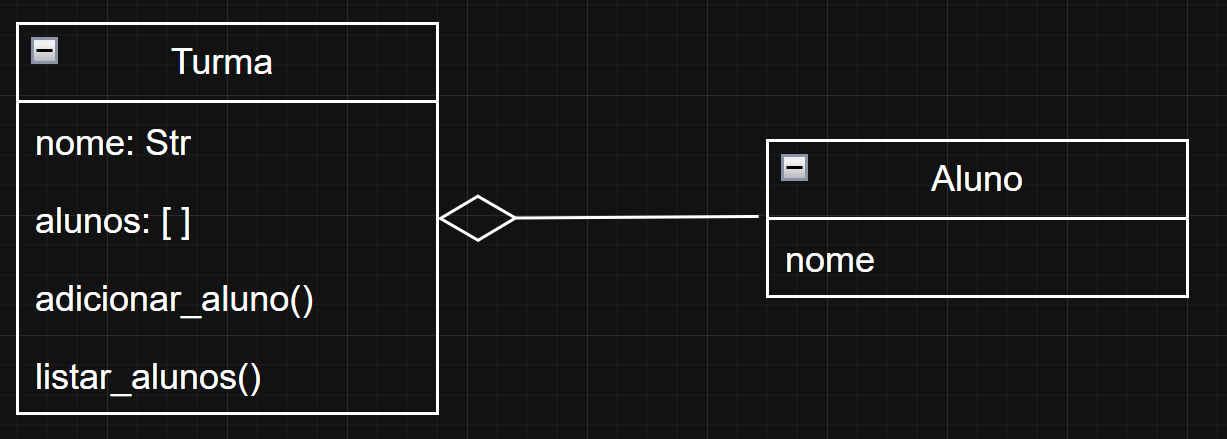

In [15]:
class Aluno:
  def __init__(self, nome):
    self.nome = nome

class Turma:
  def __init__(self, nome):
    self.nome = nome
    self.alunos = []

  def adicionar_aluno(self, aluno): # agregação
    self.alunos.append(aluno)

  def listar_alunos(self):
    print(f"Turma: {self.nome}")
    for aluno in self.alunos:
      print("-", aluno.nome)

aluno1 = Aluno("Lia")
aluno2 = Aluno("Davi")

#turma_python = Turma("Python Noturno")
#turma_python.adicionar_aluno(aluno1)
#turma_python.adicionar_aluno(aluno2)

#turma_python.listar_alunos()

print(aluno1.nome)
print(aluno2.nome)

Lia
Davi


# 6) Composição

## Conceito
A **composição** também é uma relação de todo-parte, mas agora com dependência forte.

### Ideia principal
As partes nascem dentro do todo e fazem sentido apenas ligadas a ele.

### Como aparece na UML
- linha contínua
- losango preenchido

### Leitura simples
> "Tem, com posse forte"

---

## Exemplo de contexto
Uma `Casa` possui `Comodo`s criados dentro dela.

In [18]:
class Comodo:
  def __init__(self, nome):
    self.nome = nome

class Casa:
  def __init__(self, endereco):
    self.endereco = endereco
    self.comodos = [] #composicao

  def adicionar_comodo(self, nome_comodo):
    comodo = Comodo(nome_comodo) #criado dentro de casa
    self.comodos.append(comodo)

  def mostrar_comodos(self):
    print(f"Casa localizada em: {self.endereco}")
    print("Comodos: ")
    for comodo in self.comodos:
      print("-", comodo.nome)

casa = Casa("Rua das classes, 123")
casa.adicionar_comodo("Sala")
casa.adicionar_comodo("Cozinha")

casa.mostrar_comodos()

Casa localizada em: Rua das classes, 123
Comodos: 
- Sala
- Cozinha


# Exemplo completo — Sistema de Restaurante Tech Gourmet

Agora vamos montar um exemplo maior para unir os conceitos.

## Contexto
Temos:
- `Pessoa` como classe base; OK
- `Garcom` herdando de `Pessoa`; OK
- `FormaPagamento` como contrato;
- `Pix` implementando esse contrato;
- `Pedido` associado a um `Garcom`;
- `Pedido` usando uma `Impressora` temporariamente;
- `Mesa` agregando `Cliente`s;
- `Pedido` compondo `ItemPedido`s.

In [19]:
from abc import ABC, abstractclassmethod

#HERANCA
class Pessoa:
  def __init__(self, nome):
    self.nome = nome

class Garcom(Pessoa):
  def atender(self):
    print(f"{self.nome} está atendendo a mesa.")

# AGREGACAO

class Cliente:
  def __init__(self, nome):
    self.nome = nome

class Mesa:
  def __init__(self, numero):
    self.numero = numero
    self.clientes = []

  def adicionar_cliente(self, cliente):
    self.clientes.append(cliente)

  def listar_clientes(self):
    print(f"Mesa {self.numero}")
    for cliente in self.clientes:
      print("-", cliente.nome)

#COMPOSICAO
class ItemPedido:
  def __init__(self, nome, preco):
    self.nome = nome
    self.preco = preco

# REALIZACAO / IMPLEMENTACAO
class FormaPagamento(ABC):
  @abstractclassmethod
  def pagar(self, valor):
    pass

class Pix(FormaPagamento):
  def pagar(self, valor):
    print(f"pagou nu pinks o valor de {valor:.2f}")

#DEPENDENCIA
class impressora:
  def imprimir(self, texto):
    print("==IMPRIMINDO==")
    print(texto)
    print("==============")

# ASSOCIAÇÃO + COMPOSICAO + DEPENDENCIA
class Pedido:
  def __init__(self, garcom):
    self.garcom = garcom # associacao com garcom
    self.itens = []      # composicao com ItemPedido

  def adicionar_item(self, nome, preco):
    item = ItemPedido(nome, preco)
    self.itens.append(item)

  def total(self):
    return sum(item.preco for item in self.itens)

  def resumo(self):
    linhas = [f"Garçom responsável: {self.garcom.nome}", "Itens do pedido:"]
    for item in self.itens:
      linhas.append(f"- {item.nome}: R$ {item.preco:.2f}")
    linhas.append(f"Total: R$ {self.total():.2f}")
    return "\n".join(linhas)

  def fechar_conta(self, forma_pagamento):
    valor = self.total()
    forma_pagamento.pagar(valor)

  def imprimir_pedido(self, impressora):
    impressora.imprimir(self.resumo())

garcom = Garcom("Alfredo")
garcom.atender()

mesa = Mesa(10)
mesa.adicionar_cliente(Cliente("Roberwaldo"))
mesa.adicionar_cliente(Cliente("Abigail"))
mesa.listar_clientes()

pedido = Pedido(garcom)
pedido.adicionar_item("Hamburguer", 32.90)
pedido.adicionar_item("Batata fritz", 14.50)
pedido.adicionar_item("Refrigerante", 9.00)

print("\nResumo do pedido:")
print(pedido.resumo())

pix = Pix()
pedido.fechar_conta(pix)

impressora = Impressora()
pedido.imprimir_pedido(impressora)

Alfredo está atendendo a mesa.
Mesa 10
- Roberwaldo
- Abigail

Resumo do pedido:
Garçom responsável: Alfredo
Itens do pedido:
- Hamburguer: R$ 32.90
- Batata fritz: R$ 14.50
- Refrigerante: R$ 9.00
Total: R$ 56.40
pagou nu pinks o valor de 56.40
==IMPRIMINDO==
Garçom responsável: Alfredo
Itens do pedido:
- Hamburguer: R$ 32.90
- Batata fritz: R$ 14.50
- Refrigerante: R$ 9.00
Total: R$ 56.40
